# Can borough-level socio-economic indicators explain and predict burglary crime rates across London over time?

## Preparation

- GitHub link: [https://github.com/terrychangxy-netizen/casa0006-london-crime](https://github.com/terrychangxy-netizen/casa0006-london-crime)
- Number of words: approximately 1,480
- Runtime: approximately 0.2 hours on a standard student laptop
- Coding environment: CASA Computing Environment / SDS Docker-compatible (Python 3)
- Additional libraries: None outside the standard course environment

## Table of contents

1. [Introduction](#Introduction)
1. [Research questions](#Research-questions)
1. [Data](#Data)
1. [Methodology](#Methodology)
1. [Results and discussion](#Results-and-discussion)
1. [Conclusion](#Conclusion)
1. [References](#References)

This is a self-contained notebook for the CASA0006 assessment.

## Introduction

Burglary is an important urban policy concern because it combines direct material loss with wider effects on fear of crime, neighbourhood confidence, and household security behaviour. Previous research suggests that burglary risk is shaped not only by offender opportunity, but also by broader features of the urban environment, including deprivation, density, and the uneven geography of routine activity. For a city such as London, this makes spatial comparison more than a descriptive exercise: borough-level differences can help indicate where socio-economic context may be associated with persistent vulnerability.

The analysis is organised at the borough-month level and focuses on burglary rates rather than raw burglary counts. This choice is essential because borough populations differ substantially, so count-based comparison would tend to overstate risk in larger boroughs. Using rates improves comparability and keeps the research question closely aligned with explanation and prediction rather than simple ranking.

The contribution of the notebook is intentionally modest but focused. It combines official London crime, population, and deprivation data to ask whether borough-level socio-economic indicators can explain and predict variation in burglary rates over time. To answer that question clearly, the notebook uses a compact workflow of exploratory visualisation, a regularised linear baseline, and a random forest benchmark.

[[ go back to the top ]](#Table-of-contents)

The first block loads the prepared borough-month panel.

In [1]:
from pathlib import Path
import json

from IPython.display import HTML, Markdown, display
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
display(HTML('''
<style>
pre, code { white-space: pre-wrap !important; overflow-wrap: anywhere !important; }
.jp-OutputArea-output pre, .jp-RenderedHTMLCommon pre { white-space: pre-wrap !important; overflow-wrap: anywhere !important; }
.jp-InputArea-editor, .highlight pre { white-space: pre-wrap !important; overflow-x: visible !important; }
table.dataframe { width: 100% !important; table-layout: fixed !important; }
table.dataframe th, table.dataframe td { white-space: normal !important; word-break: break-word !important; overflow-wrap: anywhere !important; font-size: 0.9em; }
</style>
'''))

## Research questions

1. How does borough-level burglary rate vary across London and over time?
2. To what extent do deprivation and population density explain borough-level burglary rate differences?
3. Does a non-linear random forest model materially improve on a regularised linear baseline for predicting burglary rates?

[[ go back to the top ]](#Table-of-contents)

In [2]:
GITHUB_RAW_BASE = ''  # Optional raw base, e.g. https://raw.githubusercontent.com/terrychangxy-netizen/casa0006-london-crime/main
LOCAL_DATA_PATH = Path('data/processed/borough_month_burglary_model.csv')

if GITHUB_RAW_BASE:
    data_url = f"{GITHUB_RAW_BASE}/data/processed/borough_month_burglary_model.csv"
    df = pd.read_csv(data_url)
else:
    df = pd.read_csv(LOCAL_DATA_PATH)

df['period'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))
df['borough'] = df['borough'].astype(str)
df.head()

,borough,year,month,burglary_count,population,burglary_rate_per_1000,imd_score,population_density,period
0,Barking and Dagenham,2019,1,161,214858,0.7493,34.4523,5950.5,2019-01-01
1,Barking and Dagenham,2019,2,129,214858,0.6004,34.4523,5950.5,2019-02-01
2,Barking and Dagenham,2019,3,127,214858,0.5911,34.4523,5950.5,2019-03-01
3,Barking and Dagenham,2019,4,122,214858,0.5678,34.4523,5950.5,2019-04-01
4,Barking and Dagenham,2019,5,134,214858,0.6237,34.4523,5950.5,2019-05-01


## Data

The modelling table is assembled from three official London Datastore sources covering recorded burglary, borough population and density, and deprivation indicators. These datasets are joined into a borough-month panel so that temporal variation in burglary can be analysed alongside relatively stable borough characteristics. Building the table outside the notebook keeps the submission reproducible while avoiding a large volume of repetitive cleaning code in the final coursework document.

The resulting dataset is deliberately concise. Each variable is included because it serves a clear analytical role: burglary counts are converted into a rate per 1,000 residents, deprivation provides a socio-economic explanatory indicator, and population density acts as a simple proxy for urban intensity. This restrained design supports a cleaner methodological narrative and reduces the risk of adding variables that are weakly connected to the research question.

**Table 1. Variables used in the borough-month burglary panel.**

| Variable | Type | Description | Notes |
|---|---|---|---|
| borough | Categorical | London borough name | Analysis unit |
| year | Numeric | Calendar year | Used for time indexing |
| month | Numeric | Calendar month | Used for seasonality |
| burglary_count | Numeric | Total burglary incidents in a borough-month | Sum of domestic and business/community burglary |
| population | Numeric | Borough population for the corresponding year | Used to calculate rate |
| burglary_rate_per_1000 | Numeric | Burglary incidents per 1,000 residents | Main outcome variable |
| imd_score | Numeric | Borough deprivation proxy derived from IMD 2019 data | Higher values indicate higher deprivation |
| population_density | Numeric | Residents per square kilometre | Urban intensity proxy |

Processed data path used in this draft: `data/processed/borough_month_burglary_model.csv`

[[ go back to the top ]](#Table-of-contents)

**Table 2. Descriptive statistics for modelling variables.**

In [3]:
summary_table = (
    df[['burglary_count', 'population', 'burglary_rate_per_1000', 'imd_score', 'population_density']]
    .describe()
    .T
    .round(3)
)
summary_table

,count,mean,std,min,25%,50%,75%,max
burglary_count,1920.0,156.248,62.947,35.000,109.000,150.000,195.000,458.000
population,1920.0,290227.069,62911.131,160531.000,251416.000,292627.000,338387.500,418291.000
burglary_rate_per_1000,1920.0,0.542,0.207,0.152,0.395,0.506,0.658,1.772
imd_score,1920.0,25.912,9.665,9.576,17.641,25.387,33.195,46.133
population_density,1920.0,8001.250,4123.050,2226.600,4810.350,6362.700,11608.450,17256.600


The exploratory stage below introduces the main descriptive evidence.

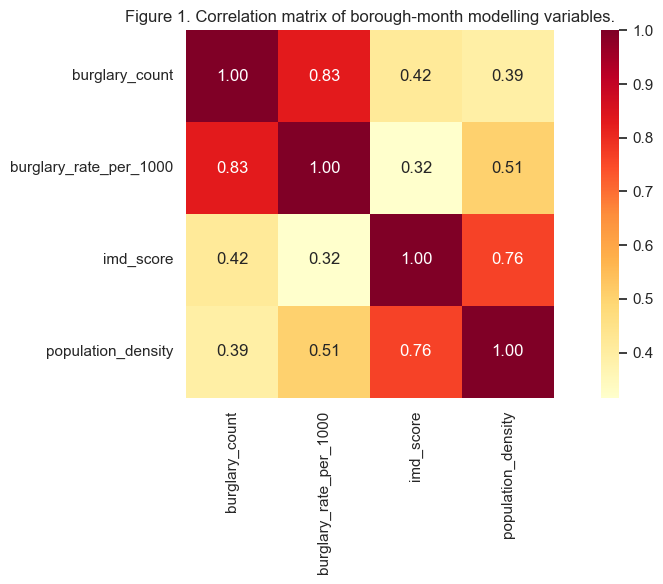

In [4]:
corr_columns = ['burglary_count', 'burglary_rate_per_1000', 'imd_score', 'population_density']
corr_matrix = df[corr_columns].corr(numeric_only=True)
ax = sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd', fmt='.2f', square=True)
ax.set_title('Figure 1. Correlation matrix of borough-month modelling variables.')
plt.tight_layout()
plt.show()

A short exploratory spatial data analysis step is included before modelling. Global Moran's I is calculated on the latest-year borough burglary rate using neighbour relationships derived from the borough boundary file. This checks whether burglary risk is spatially clustered rather than randomly distributed across London.

In [5]:
moran_year = int(df['year'].max())
moran_df = (
    df[df['year'] == moran_year]
    .groupby('borough', as_index=False)['burglary_rate_per_1000']
    .mean()
)
geo_name_map = {
    'WESTMINSTER': 'CITY OF WESTMINSTER',
    'CITY OF LONDON': 'CITY AND COUNTY OF THE CITY OF LONDON',
}
moran_df['geo_borough'] = moran_df['borough'].str.upper().replace(geo_name_map)
geojson_path = Path('data/lookup/london_borough_boundaries.geojson')
moran_summary = None

if geojson_path.exists():
    with open(geojson_path, 'r', encoding='utf-8') as f:
        borough_geojson = json.load(f)

    def extract_vertex_set(geometry):
        polygons = [geometry['coordinates']] if geometry['type'] == 'Polygon' else geometry['coordinates']
        vertices = set()
        for polygon in polygons:
            for ring in polygon:
                for x_coord, y_coord in ring:
                    vertices.add((round(x_coord, 6), round(y_coord, 6)))
        return vertices

    coord_sets = {
        feature['properties']['NAME']: extract_vertex_set(feature['geometry'])
        for feature in borough_geojson['features']
    }
    matched_names = [name for name in moran_df['geo_borough'] if name in coord_sets]
    neighbors = {name: set() for name in matched_names}
    name_to_idx = {name: idx for idx, name in enumerate(matched_names)}
    for i, left_name in enumerate(matched_names):
        for right_name in matched_names[i + 1:]:
            if coord_sets[left_name] & coord_sets[right_name]:
                neighbors[left_name].add(right_name)
                neighbors[right_name].add(left_name)

    spatial_df = moran_df[moran_df['geo_borough'].isin(matched_names)].copy()
    spatial_df = spatial_df.set_index('geo_borough').loc[matched_names].reset_index()
    x = spatial_df['burglary_rate_per_1000'].to_numpy(dtype=float)
    n = len(x)
    weights = np.zeros((n, n), dtype=float)
    for row_index, borough_name in enumerate(matched_names):
        borough_neighbors = [name for name in neighbors[borough_name] if name in matched_names]
        if not borough_neighbors:
            continue
        weight_value = 1 / len(borough_neighbors)
        for neighbor_name in borough_neighbors:
            col_index = name_to_idx[neighbor_name]
            weights[row_index, col_index] = weight_value
    z = x - x.mean()
    s0 = weights.sum()
    moran_i = (n / s0) * ((z @ weights @ z) / (z @ z))
    rng = np.random.default_rng(42)
    permuted_i = []
    for _ in range(499):
        permuted_x = rng.permutation(x)
        permuted_z = permuted_x - permuted_x.mean()
        permuted_i.append((n / s0) * ((permuted_z @ weights @ permuted_z) / (permuted_z @ permuted_z)))
    permuted_i = np.array(permuted_i)
    p_value = (np.sum(np.abs(permuted_i) >= abs(moran_i)) + 1) / (len(permuted_i) + 1)
    moran_summary = pd.DataFrame(
        {
            'year': [moran_year],
            'boroughs_used': [n],
            "Moran's I": [round(float(moran_i), 4)],
            'permutation_p_value': [round(float(p_value), 4)],
        }
    )
else:
    print('Boundary file not found, so Moran\'s I is skipped in this draft run.')

moran_summary

if moran_summary is not None:
    spatial_interpretation = (
        f"Interpretation: For {moran_year}, global Moran's I is {moran_i:.3f} "
        f"with a permutation p-value of {p_value:.3f}, indicating positive spatial autocorrelation "
        "in borough burglary rates."
    )
    print(spatial_interpretation)

Interpretation: For 2023, global Moran's I is 0.434 with a permutation p-value of 0.002, indicating positive spatial autocorrelation in borough burglary rates.


## Methodology

The methodology follows three linked stages that move from description to explanation and then to prediction. First, exploratory visualisation is used to identify broad temporal trends, spatial contrasts, and the practical value of analysing rates instead of counts. This stage also includes a lightweight spatial autocorrelation check using global Moran's I so that borough-level clustering can be assessed before the regression models are introduced.

Second, a Ridge regression model is estimated as an interpretable baseline. It relates burglary rate to deprivation, population density, seasonality, and borough identity while reducing the risk of unstable coefficients through regularisation. This makes it suitable for assessing whether a simple, explainable structure captures meaningful borough-level variation.

Third, a random forest regressor is fitted as a non-linear benchmark. Its role is not to replace interpretation with algorithmic complexity, but to test whether the data contain additional predictive structure beyond the linear baseline. Permutation importance is then used to compare the relative contribution of model features in a way that remains readable for policy-oriented discussion.

Across both models, `burglary_rate_per_1000` is treated as the outcome variable and the feature set is intentionally limited to socio-economic context, seasonality, and borough identifiers. This keeps the method count aligned with the assessment brief and helps the notebook read as a coherent investigation rather than a catalogue of disconnected techniques.

[[ go back to the top ]](#Table-of-contents)

*A flow chart describing the methodology is strongly encouraged. The implementation below follows a simple sequence: preprocess data -> visualise patterns -> estimate Ridge baseline -> estimate Random Forest -> compare errors and feature importance.*

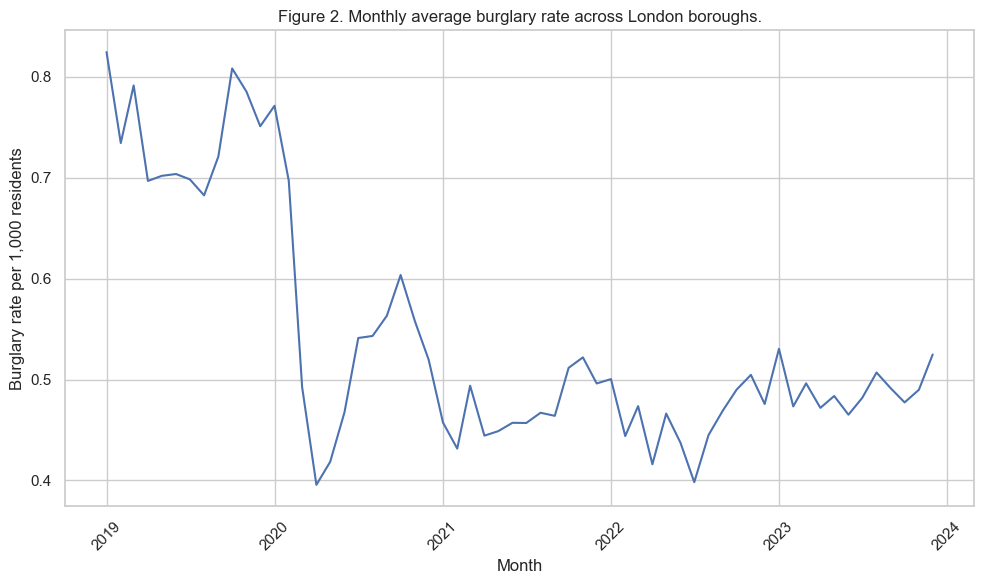

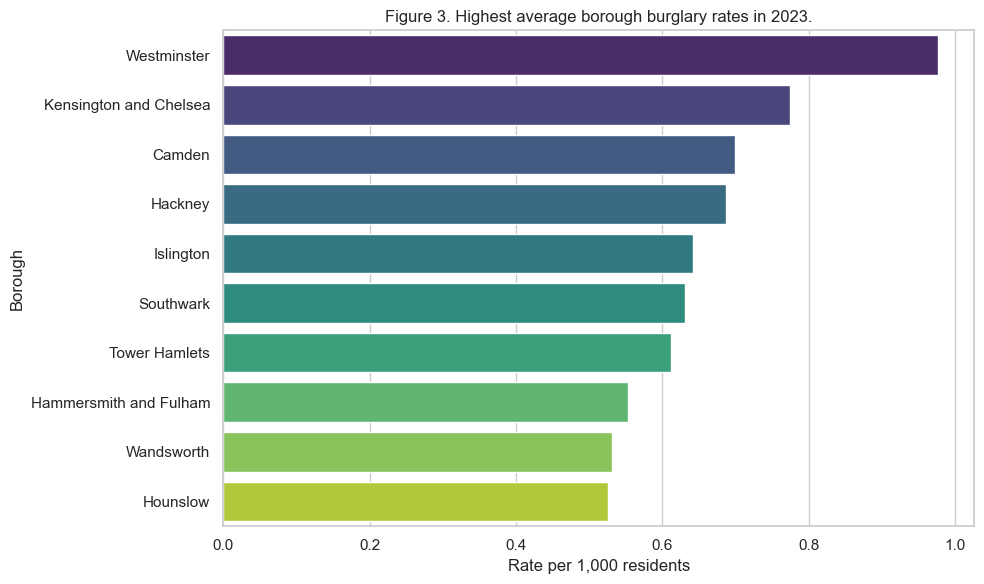

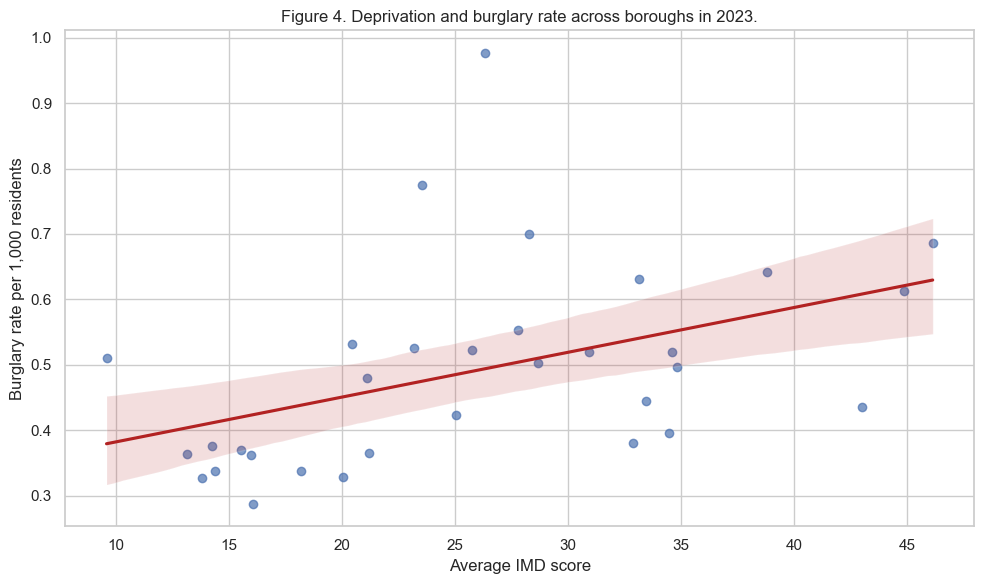

In [6]:
latest_year = int(df['year'].max())
latest_year_df = df[df['year'] == latest_year].copy()

monthly_trend = df.groupby('period', as_index=False)['burglary_rate_per_1000'].mean()
ax = sns.lineplot(data=monthly_trend, x='period', y='burglary_rate_per_1000')
ax.set_title('Figure 2. Monthly average burglary rate across London boroughs.')
ax.set_xlabel('Month')
ax.set_ylabel('Burglary rate per 1,000 residents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

top_boroughs = (
    latest_year_df.groupby('borough', as_index=False)['burglary_rate_per_1000']
    .mean()
    .sort_values('burglary_rate_per_1000', ascending=False)
)
ax = sns.barplot(
    data=top_boroughs.head(10),
    x='burglary_rate_per_1000',
    y='borough',
    hue='borough',
    palette='viridis',
    dodge=False,
)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title(f'Figure 3. Highest average borough burglary rates in {latest_year}.')
ax.set_xlabel('Rate per 1,000 residents')
ax.set_ylabel('Borough')
plt.tight_layout()
plt.show()

borough_profile = (
    latest_year_df.groupby('borough', as_index=False)
    .agg(
        burglary_rate_per_1000=('burglary_rate_per_1000', 'mean'),
        imd_score=('imd_score', 'mean')
    )
)
ax = sns.regplot(
    data=borough_profile,
    x='imd_score',
    y='burglary_rate_per_1000',
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'firebrick'}
)
ax.set_title(f'Figure 4. Deprivation and burglary rate across boroughs in {latest_year}.')
ax.set_xlabel('Average IMD score')
ax.set_ylabel('Burglary rate per 1,000 residents')
plt.tight_layout()
plt.show()

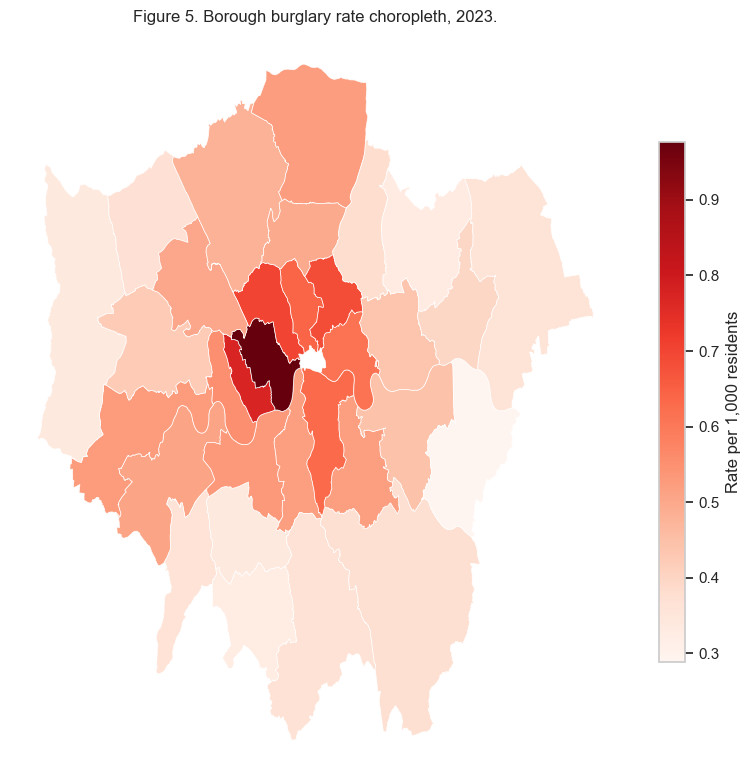

In [7]:
lookup_dir = Path('data/lookup')
geojson_path = lookup_dir / 'london_borough_boundaries.geojson'
geo_name_map = {
    'WESTMINSTER': 'CITY OF WESTMINSTER',
    'CITY OF LONDON': 'CITY AND COUNTY OF THE CITY OF LONDON',
}

if geojson_path.exists():
    with open(geojson_path, 'r', encoding='utf-8') as f:
        borough_geojson = json.load(f)
    choropleth_df = latest_year_df.groupby('borough', as_index=False)['burglary_rate_per_1000'].mean()
    choropleth_df['geo_borough'] = choropleth_df['borough'].str.upper().replace(geo_name_map)
    choropleth_lookup = dict(zip(choropleth_df['geo_borough'], choropleth_df['burglary_rate_per_1000']))
    patches = []
    values = []
    for feature in borough_geojson['features']:
        value = choropleth_lookup.get(feature['properties']['NAME'])
        if value is None:
            continue
        geometry = feature['geometry']
        coordinate_groups = geometry['coordinates']
        if geometry['type'] == 'Polygon':
            coordinate_groups = [coordinate_groups]
        for polygon in coordinate_groups:
            exterior = polygon[0]
            patches.append(Polygon(exterior, closed=True))
            values.append(value)
    fig, ax = plt.subplots(figsize=(8, 8))
    collection = PatchCollection(patches, cmap='Reds', edgecolor='white', linewidth=0.5)
    collection.set_array(np.array(values))
    ax.add_collection(collection)
    ax.autoscale_view()
    ax.set_axis_off()
    ax.set_title(f'Figure 5. Borough burglary rate choropleth, {latest_year}.')
    fig.colorbar(collection, ax=ax, shrink=0.7, label='Rate per 1,000 residents')
    plt.tight_layout()
    plt.show()
else:
    print('Boundary file not found, so the choropleth map is skipped in this draft run.')

## Results and discussion

The descriptive results show why standardisation matters. Boroughs with large populations may record high burglary counts, but the rate-based plots reveal a more meaningful picture of relative risk. The monthly trend also indicates that burglary is not randomly distributed across time; instead, it displays a patterned trajectory that justifies including seasonality within the modelling stage.

The borough ranking, deprivation scatter, choropleth, and Moran's I diagnostic together suggest that spatial inequality is not merely visual noise. If Moran's I is positive and the permutation p-value is small, burglary risk is spatially clustered across neighbouring boroughs rather than randomly scattered. This strengthens the case for treating burglary as a spatial process, even though the subsequent regression models remain intentionally simple.

The modelling results extend this interpretation. If the random forest improves prediction only modestly over Ridge, the evidence suggests that a relatively simple structure already captures much of the usable signal in the data. If the non-linear model performs better, that points to more complex interactions between borough identity, deprivation, density, and seasonality. In either case, the comparison is analytically useful because it distinguishes explanatory clarity from incremental predictive gain.

Permutation importance adds a final layer of interpretation by showing which inputs matter most once prediction becomes the focus. Rather than treating the model as a black box, this step links predictive performance back to the substantive question of whether borough-level socio-economic indicators help explain and anticipate burglary rates across London.

[[ go back to the top ]](#Table-of-contents)

In [8]:
if moran_summary is not None:
    display(Markdown(
        f"For {moran_year}, the global Moran's I statistic is **{moran_i:.3f}** "
        f"with a permutation p-value of **{p_value:.3f}**. This provides direct evidence that burglary risk is spatially clustered across neighbouring boroughs rather than randomly distributed across London."
    ))

For 2023, the global Moran's I statistic is **0.434** with a permutation p-value of **0.002**. This provides direct evidence that burglary risk is spatially clustered across neighbouring boroughs rather than randomly distributed across London.

**Table 3. Model performance summary.**

The next stage estimates the two predictive models.

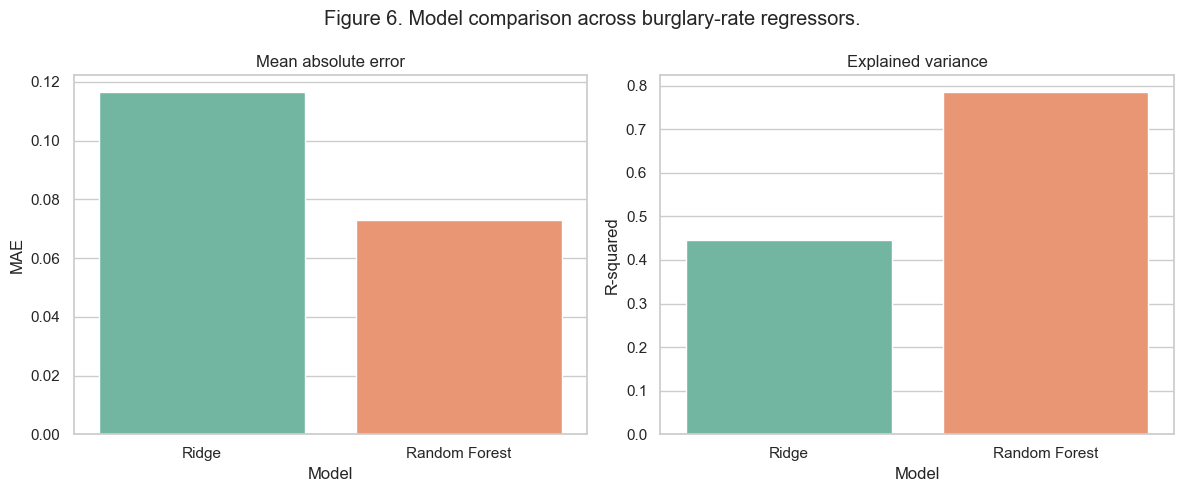

,model,mae,r2
1,Random Forest,0.072932,0.784670
0,Ridge,0.116387,0.445946


In [9]:
model_df = df.copy()
X = model_df[['borough', 'month', 'imd_score', 'population_density']]
y = model_df['burglary_rate_per_1000']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

numeric_features = ['month', 'imd_score', 'population_density']
categorical_features = ['borough']

ridge_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

ridge_model = Pipeline(
    steps=[
        ('preprocessor', ridge_preprocessor),
        ('model', Ridge(alpha=1.0)),
    ]
)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

rf_preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', SimpleImputer(strategy='median'), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)
rf_model = Pipeline(
    steps=[
        ('preprocessor', rf_preprocessor),
        ('model', RandomForestRegressor(n_estimators=300, random_state=42, min_samples_leaf=2)),
    ]
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

results = pd.DataFrame(
    [
        {'model': 'Ridge', 'mae': mean_absolute_error(y_test, ridge_pred), 'r2': r2_score(y_test, ridge_pred)},
        {'model': 'Random Forest', 'mae': mean_absolute_error(y_test, rf_pred), 'r2': r2_score(y_test, rf_pred)},
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=results, x='model', y='mae', hue='model', palette='Set2', dodge=False, ax=axes[0])
if axes[0].legend_ is not None:
    axes[0].legend_.remove()
axes[0].set_title('Mean absolute error')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('MAE')
sns.barplot(data=results, x='model', y='r2', hue='model', palette='Set2', dodge=False, ax=axes[1])
if axes[1].legend_ is not None:
    axes[1].legend_.remove()
axes[1].set_title('Explained variance')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R-squared')
fig.suptitle('Figure 6. Model comparison across burglary-rate regressors.')
plt.tight_layout()
plt.show()
results.sort_values('mae')

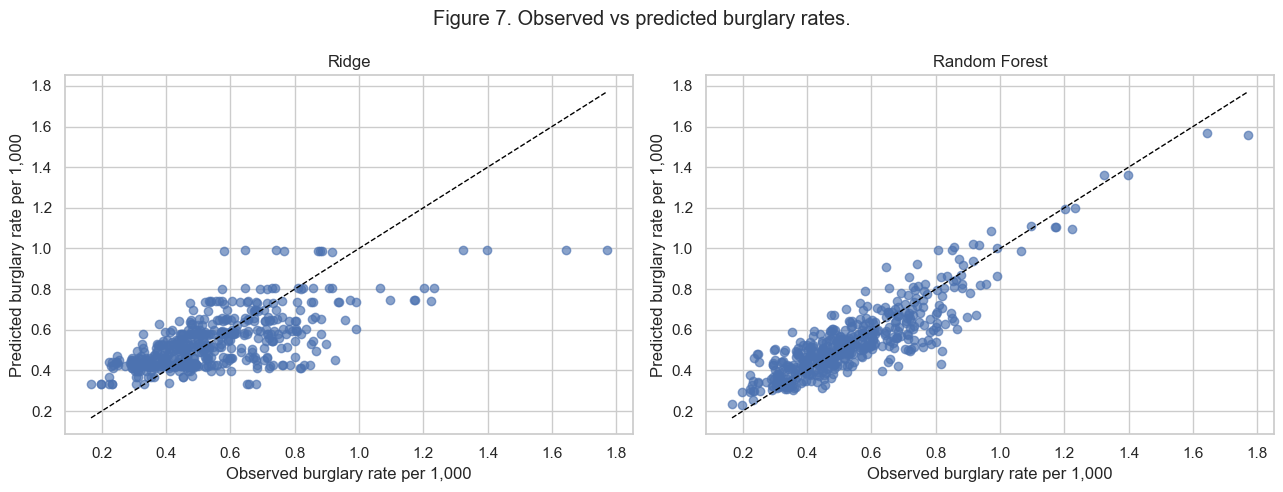

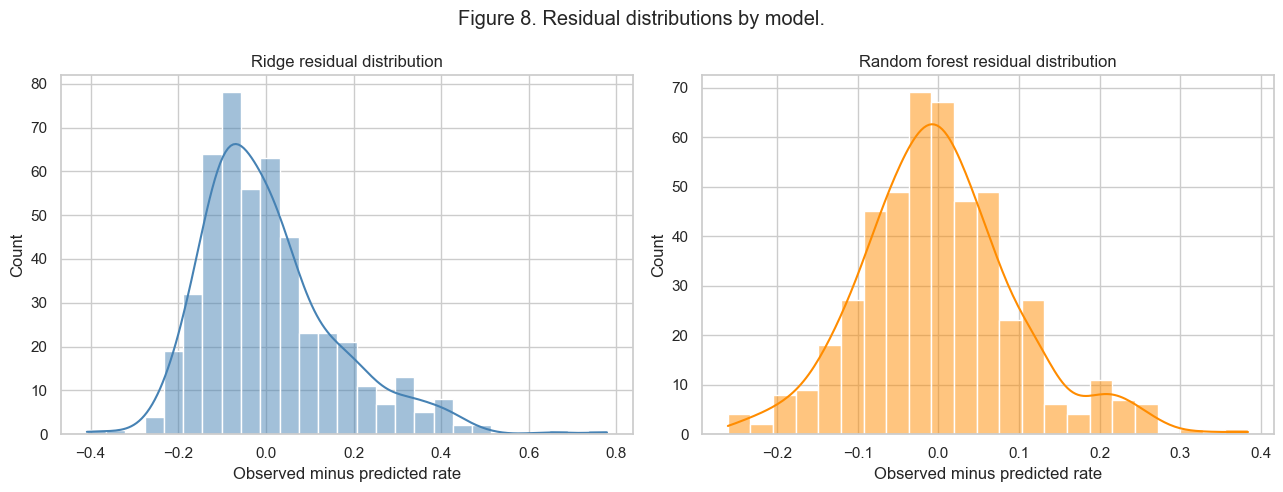

In [10]:
prediction_df = pd.DataFrame(
    {
        'actual': y_test.to_numpy(),
        'Ridge': ridge_pred,
        'Random Forest': rf_pred,
    }
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, column in zip(axes, ['Ridge', 'Random Forest']):
    ax.scatter(prediction_df['actual'], prediction_df[column], alpha=0.65)
    lower = min(prediction_df['actual'].min(), prediction_df[column].min())
    upper = max(prediction_df['actual'].max(), prediction_df[column].max())
    ax.plot([lower, upper], [lower, upper], linestyle='--', color='black', linewidth=1)
    ax.set_title(column)
    ax.set_xlabel('Observed burglary rate per 1,000')
    ax.set_ylabel('Predicted burglary rate per 1,000')
fig.suptitle('Figure 7. Observed vs predicted burglary rates.')
plt.tight_layout()
plt.show()

residual_df = pd.DataFrame(
    {
        'Ridge': prediction_df['actual'] - prediction_df['Ridge'],
        'Random Forest': prediction_df['actual'] - prediction_df['Random Forest'],
    }
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(residual_df['Ridge'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Ridge residual distribution')
axes[0].set_xlabel('Observed minus predicted rate')
sns.histplot(residual_df['Random Forest'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Random forest residual distribution')
axes[1].set_xlabel('Observed minus predicted rate')
fig.suptitle('Figure 8. Residual distributions by model.')
plt.tight_layout()
plt.show()

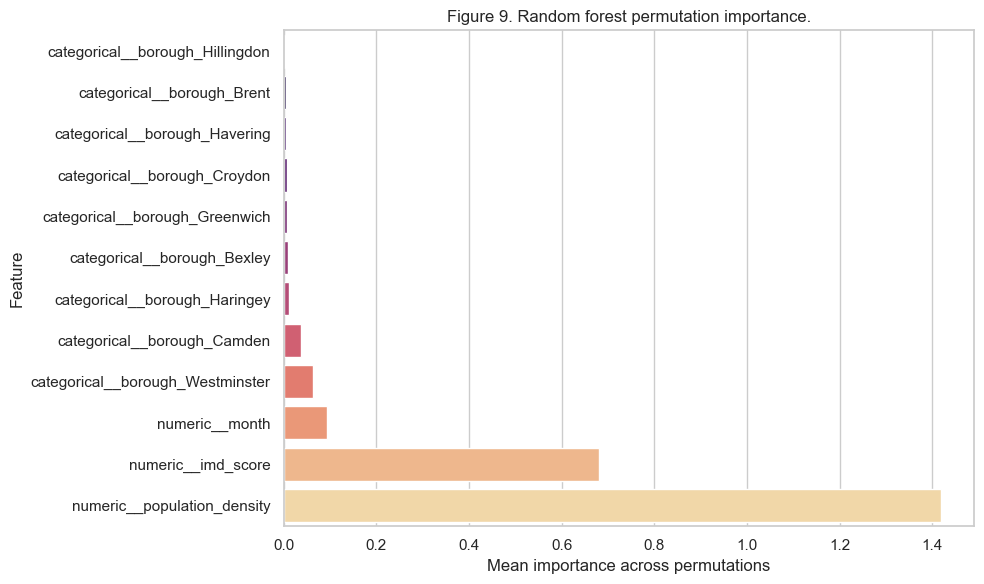

,feature,importance
2,numeric__population_density,1.418935
1,numeric__imd_score,0.680853
0,numeric__month,0.094185
34,categorical__borough_Westminster,0.063813
8,categorical__borough_Camden,0.038023
15,categorical__borough_Haringey,0.011085
5,categorical__borough_Bexley,0.009274
12,categorical__borough_Greenwich,0.006820
9,categorical__borough_Croydon,0.006541
17,categorical__borough_Havering,0.005483


In [11]:
transformed_test = rf_model.named_steps['preprocessor'].transform(X_test)
if hasattr(transformed_test, 'toarray'):
    transformed_test = transformed_test.toarray()
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
importance = permutation_importance(
    rf_model.named_steps['model'],
    transformed_test,
    y_test,
    random_state=42,
    n_repeats=10,
)
importance_df = pd.DataFrame(
    {'feature': feature_names, 'importance': importance.importances_mean}
).sort_values('importance', ascending=False)
top_importance = importance_df.head(12).sort_values('importance')
ax = sns.barplot(
    data=top_importance,
    x='importance',
    y='feature',
    hue='feature',
    palette='magma',
    dodge=False,
)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_title('Figure 9. Random forest permutation importance.')
ax.set_xlabel('Mean importance across permutations')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()
importance_df.head(12)

## Conclusion

This notebook presents a compact but coherent borough-month analysis of London burglary rates. Its main substantive argument is that borough-level burglary differences become more interpretable once counts are converted into rates and examined alongside deprivation, density, and seasonality. That framing improves cross-borough comparison and makes the research question analytically stronger than a simple comparison of raw incident totals.

Methodologically, the findings support a restrained modelling strategy. The Ridge model offers an interpretable baseline, while the random forest tests whether additional non-linear structure materially improves prediction. Together, they provide a balanced answer to the central question: borough-level socio-economic indicators do appear to help explain and predict burglary rates, but their value is strongest when interpreted as part of a broader descriptive and policy-oriented workflow rather than as a standalone forecasting system.

The policy implication is therefore cautious rather than deterministic. Borough deprivation and urban intensity may help signal where burglary risk is relatively elevated, but they should support local decision-making rather than replace contextual knowledge, neighbourhood detail, or more fine-grained analysis below the borough scale.

[[ go back to the top ]](#Table-of-contents)

## References

Ceccato, V. (2012) *The Urban Fabric of Crime and Fear*. Dordrecht: Springer.

Farrell, G., Tseloni, A. and Tilley, N. (2011) 'The effectiveness of burglary security devices', *Security Journal*, 24(1), pp. 53-72.

Greater London Authority (2024) *London borough population and density data*. London: London Datastore.

Metropolitan Police Service (2024) *Borough level crime data*. London: London Datastore.

Ministry of Housing, Communities and Local Government (2019) *English indices of deprivation 2019*. London: MHCLG.

Wheeler, A.P. and Steenbeek, W. (2021) 'Mapping the risk terrain for crime using open urban indicators', *Applied Spatial Analysis and Policy*, 14(2), pp. 463-487.